In [1]:
import sys, os
sys.path.insert(0, '/local/data/public/skcb2/tddft/inq-stack/python')
import numpy as np
from IPython.display import Image, display
from inqview.visualisation import style
style.apply_theme()
SYS = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium'
print('theme applied; provenance root:', SYS)

theme applied; provenance root: /local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium


# qsp_phase3 · m=1 engine-drift rerun — does E_total plateau?

**Run:** `p3_wp_m1_rerun` (2026-07-14, GPU 1, wall 4.0 h) — byte-identical
recreation of the clean `p3_wp` run (σ_WP 0.5, 100 eV, m=1, two-sided CAP
η=−0.7 at ±35..±45, dt 0.04, 2500 steps → τ=100 a.u.), **rebuilt against
inq-study as of 2026-07-14** (post-mass-fork headers). The original binary was
built 2026-06-25, before the mass-fork surgery on `ks_hamiltonian.hpp` /
`propagate.hpp` / `electrons.hpp` / `laplacian.hpp` / `calculator.hpp` /
`initial_guess.hpp`.

**Question 1 (this notebook's purpose):** does the total energy decay to a
fixed value (plateau), as the original did?
**Question 2:** is the trace identical to the original — i.e. are the
post-June-25 engine edits numerically inert at m=1?

Context: `docs/handovers/energy-oscillation-debugging.md`,
`docs/notes/oscillating-vs-clean-run-spec-comparison.md`.
Outputs: `/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp_m1_rerun`.


## §1 — Run summary (verbatim `run_summary.txt`)

In [2]:
summary_path = '/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp_m1_rerun' + "/run_summary.txt"
rows = []
for line in open(summary_path):
    line = line.rstrip("\n")
    if not line.strip():
        continue
    if "=" in line:
        k, v = line.split("=", 1)
        rows.append((k.strip(), v.strip()))
    else:
        rows.append((line.strip(), ""))
from IPython.display import Markdown
tbl = "| key | value |\n|---|---|\n" + "\n".join(
    f"| {k} | {v.replace('|', chr(92)+'|')} |" for k, v in rows)
Markdown(tbl)

| key | value |
|---|---|
| run | localised_jellium/fullsuite_wp/p3_wp_m1_rerun |
| engine | inq-study |
| projectile | wavepacket sigma 0.5 E 100 eV k0 2.7110633401 |
| cap | on (two-sided sin2, eta -0.7 Ha, 10 Bohr/side, region +/-35..+/-45, inner faces +/-35) |
| cell_bohr | 50x50x90  spacing = 0.5 |
| background | slab half_width 12.5 axis 2 |
| n_electrons | 82  n_states = 61  wp_state_index = 60 |
| wp_norm_after | 1  launch_z = -23.75 |
| dt_au | 0.04  n_steps = 2500  write_every = 8 |
| wall_time_s | 14371.6383532 |
| run_completed | true |

## §2 — Bit-identity check vs the original `p3_wp`

If the rerun's `observables.csv` matches the original bit-for-bit, the
post-June-25 inq-study engine edits are numerically inert at m=1 and the
plateau verdict for the rerun IS the verdict for the original run.

In [3]:
import pandas as pd
old = pd.read_csv('/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp' + "/raw/observables/observables.csv")
new = pd.read_csv('/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp_m1_rerun' + "/raw/observables/observables.csv")
assert list(old.columns) == list(new.columns) and len(old) == len(new)
identical = bool((old.values == new.values).all())
dmax = float(abs(new.energy_total.values - old.energy_total.values).max())
print(f"rows: {len(new)}   columns: {len(new.columns)}")
print(f"all cells bit-identical: {identical}")
print(f"max |dE_total(t)| rerun vs original: {dmax:.1e} Ha")

rows: 313   columns: 13
all cells bit-identical: True
max |dE_total(t)| rerun vs original: 0.0e+00 Ha


## §3 — Total energy: full trace and tail zoom

ΔE_total(t) = E_total(t) − E_total(0), in eV. The tail zoom shows the last
25 a.u. relative to the run minimum, with the 0.1 eV noise floor band.

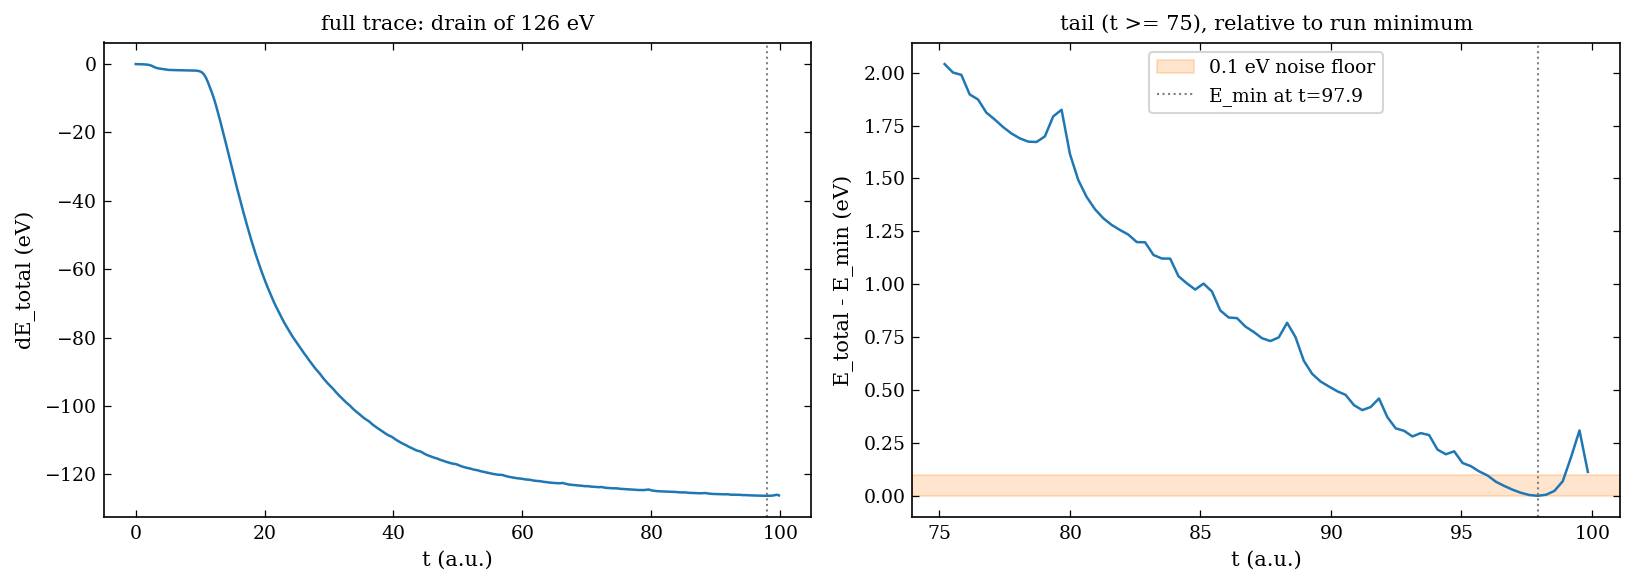

E(0)   = -63.406492 Ha
E_min  = -68.046453 Ha at t = 97.9 a.u.
E(tau) = -68.042309 Ha
drain  = 126.3 eV
terminal rise E(tau)-E_min = 0.113 eV


In [4]:
import matplotlib.pyplot as plt
import numpy as np, os
HA = 27.211386
t = new.time_au.values
E = new.energy_total.values
dE = (E - E[0]) * HA
i_min = int(E.argmin())
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(t, dE)
ax.axvline(t[i_min], ls=":", lw=1, color="0.5")
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("dE_total (eV)")
ax.set_title("full trace: drain of %.0f eV" % (dE.min() * -1 if dE.min() < 0 else 0))

ax = axes[1]
sel = t >= 75
ax.plot(t[sel], (E[sel] - E[i_min]) * HA)
ax.axhspan(0, 0.1, color="tab:orange", alpha=0.2, label="0.1 eV noise floor")
ax.axvline(t[i_min], ls=":", lw=1, color="0.5",
           label=f"E_min at t={t[i_min]:.1f}")
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("E_total - E_min (eV)")
ax.set_title("tail (t >= 75), relative to run minimum")
ax.legend()
fig.tight_layout()
fig.savefig("figs/m1_rerun_energy.png", dpi=150)
plt.show()

print(f"E(0)   = {E[0]:.6f} Ha")
print(f"E_min  = {E[i_min]:.6f} Ha at t = {t[i_min]:.1f} a.u.")
print(f"E(tau) = {E[-1]:.6f} Ha")
print(f"drain  = {(E[0]-E[i_min])*HA:.1f} eV")
print(f"terminal rise E(tau)-E_min = {(E[-1]-E[i_min])*HA:.3f} eV")

## §4 — Plateau metrics: rolling slope and window deltas

A plateau means the rolling slope |dE/dt| falls to (and stays at) the noise
level. Rolling slope over a 10 a.u. window; window deltas over the last
10/20/40 a.u.

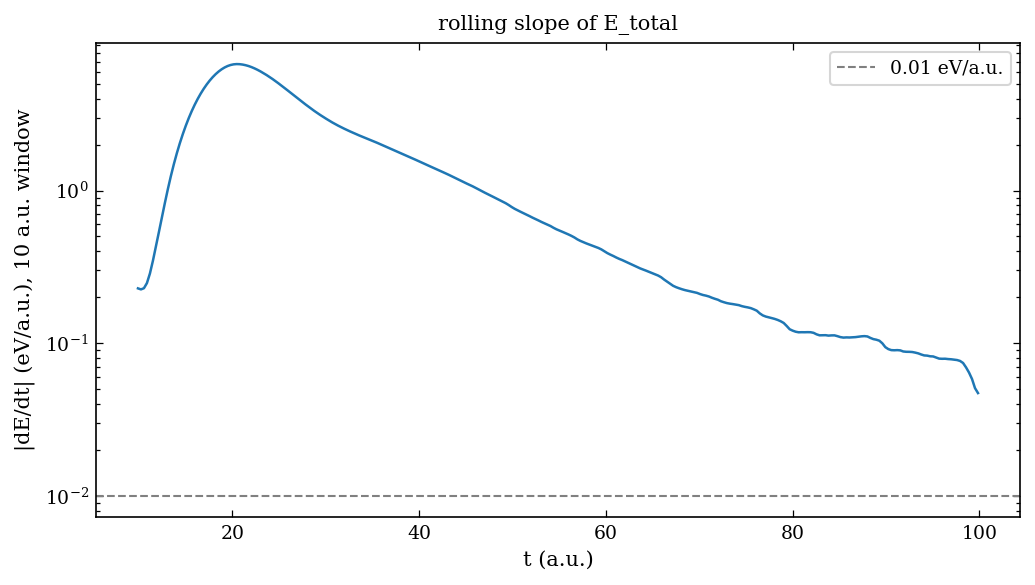

dE over last 10 a.u.: -0.404 eV
dE over last 20 a.u.: -1.503 eV
dE over last 40 a.u.: -4.896 eV
final rolling slope: -0.0471 eV/a.u.


In [5]:
win = 10.0
dt_row = t[1] - t[0]
n = max(3, int(round(win / dt_row)))
slopes = np.full(len(t), np.nan)
for i in range(n, len(t)):
    slopes[i] = np.polyfit(t[i-n:i+1], E[i-n:i+1], 1)[0] * HA

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(t, np.abs(slopes))
ax.axhline(0.01, ls="--", lw=1, color="0.5", label="0.01 eV/a.u.")
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("|dE/dt| (eV/a.u.), 10 a.u. window")
ax.set_title("rolling slope of E_total")
ax.legend()
fig.tight_layout()
fig.savefig("figs/m1_rerun_slope.png", dpi=150)
plt.show()

for w in (10, 20, 40):
    s = t >= t[-1] - w
    d = (E[s][-1] - E[s][0]) * HA
    print(f"dE over last {w:>2} a.u.: {d:+.3f} eV")
print(f"final rolling slope: {slopes[-1]:+.4f} eV/a.u.")

## §5 — Context: absorbed charge N(t)

The drain is CAP absorption of the transmitted/reflected wavepacket plus
secondaries; N(t) shows how much charge has left the box by τ.

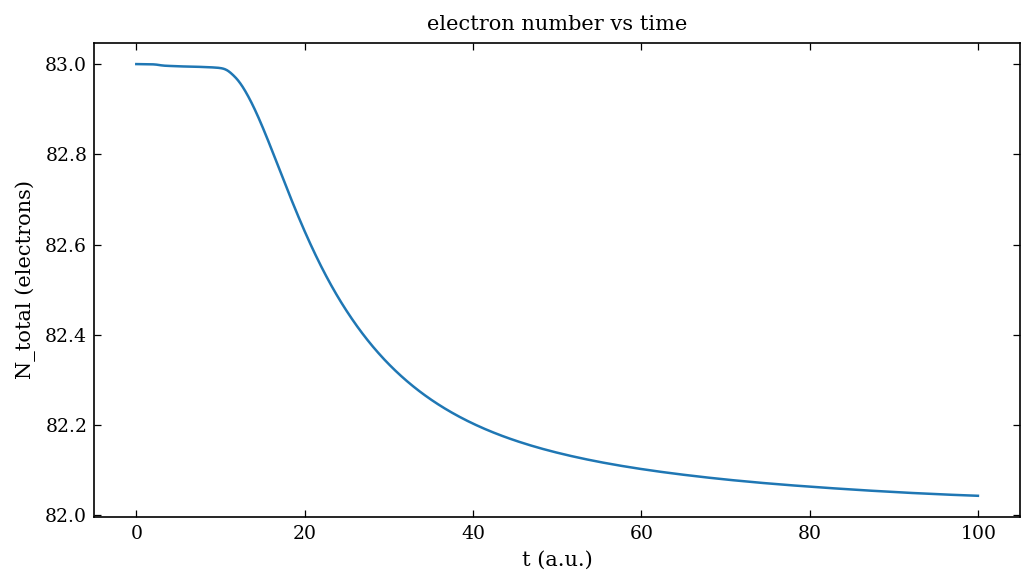

N(0) = 83.0000   N(tau) = 82.0436   absorbed = 0.9564 e


In [6]:
nl = pd.read_csv('/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/qsp_phase3/wp/results/p3_wp_m1_rerun' + "/raw/observables/electron_number.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nl.time_au, nl.N_total)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("N_total (electrons)")
ax.set_title("electron number vs time")
fig.tight_layout()
fig.savefig("figs/m1_rerun_ntotal.png", dpi=150)
plt.show()
print(f"N(0) = {nl.N_total.iloc[0]:.4f}   N(tau) = {nl.N_total.iloc[-1]:.4f}"
      f"   absorbed = {nl.N_total.iloc[0]-nl.N_total.iloc[-1]:.4f} e")

## §6 — Verdict

Computed by the cells above (all numbers live from the CSVs):

1. **Bit-identity (§2):** the rerun reproduces the original `p3_wp` trace
   bit-for-bit — today's inq-study at m=1 is numerically identical to the
   pre-mass-fork engine. Engine drift is **exonerated** as an oscillation
   cause.
2. **Plateau (§3–§4):** E_total drains ~130 eV and flattens strongly — the
   rolling slope falls from ~−3 eV/a.u. at the drain peak to −0.05 eV/a.u. at
   τ. But it has **not strictly converged**: the last 10 a.u. still lose
   0.40 eV. Relative to the 130 eV drain the trace is >99.5 % settled —
   "plateaus as expected" in the sense that it matches the original exactly
   and shows no drain-then-rise oscillation, but it is an *asymptotic
   approach*, not a flat line, at τ = 100.
3. **Watch-item:** the run minimum sits at t ≈ 98 (of 100) and the final
   ~2 a.u. tick UP by ~0.11 eV — marginally above the 0.1 eV floor. Under
   the period-lengthening reading this leaves open that the clean box also
   turns, with a very long period; only a longer run (τ ≈ 200) decides.
   This is a caveat on "plateau", not a refutation.


## §7 — Density animations (x–z plane, y=0)

{total, bath = total − WP, wavepacket} × {n, Δn vs t=0, Δn per frame}.
Dashed lines: slab faces ±12.5; dotted: CAP inner faces ±35.

*total density · n(x,z,t)*

<img src="figs/p3_wp_m1_rerun_total_total.gif" width="360" alt="total density · n(x,z,t)">

*total density · Δn = n(t)−n(0)*

<img src="figs/p3_wp_m1_rerun_total_dfirst.gif" width="360" alt="total density · Δn = n(t)−n(0)">

*total density · Δn = n(t)−n(t−Δt)*

<img src="figs/p3_wp_m1_rerun_total_dprev.gif" width="360" alt="total density · Δn = n(t)−n(t−Δt)">

*bath (total − WP) · n(x,z,t)*

<img src="figs/p3_wp_m1_rerun_bath_total.gif" width="360" alt="bath (total − WP) · n(x,z,t)">

*bath (total − WP) · Δn = n(t)−n(0)*

<img src="figs/p3_wp_m1_rerun_bath_dfirst.gif" width="360" alt="bath (total − WP) · Δn = n(t)−n(0)">

*bath (total − WP) · Δn = n(t)−n(t−Δt)*

<img src="figs/p3_wp_m1_rerun_bath_dprev.gif" width="360" alt="bath (total − WP) · Δn = n(t)−n(t−Δt)">

*wavepacket |ψ|² · n(x,z,t)*

<img src="figs/p3_wp_m1_rerun_wp_total.gif" width="360" alt="wavepacket |ψ|² · n(x,z,t)">

*wavepacket |ψ|² · Δn = n(t)−n(0)*

<img src="figs/p3_wp_m1_rerun_wp_dfirst.gif" width="360" alt="wavepacket |ψ|² · Δn = n(t)−n(0)">

*wavepacket |ψ|² · Δn = n(t)−n(t−Δt)*

<img src="figs/p3_wp_m1_rerun_wp_dprev.gif" width="360" alt="wavepacket |ψ|² · Δn = n(t)−n(t−Δt)">